In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv("/content/placement.csv")
# this will use the importated pandas library and read the csv file
# here df is data frame


# New Section

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df=df.iloc[:,1:]
# this is the first step of preprocessing
# this function help to remove the unwanted first column from out data set
# : selects all rows.
# 1: selects all columns starting from index 1 (the second column) to the end, leaving out index 0 (the first column).

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


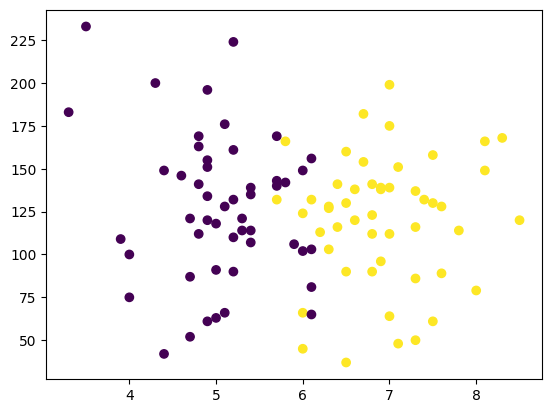

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['iq'],c=df['placement'])
# this is second step EDA
# It is the critical first step where data scientists use statistics and pictures to study a dataset before building a model.
# The main goal is to find patterns, spot mistakes, and understand what the data looks like

In [ ]:
# Extract input features (CGPA and IQ)
X = df[['cgpa', 'iq']]
# this is independent variable where this two thing are not dependent on each other which we say

# Extract target output (Placement)
y = df['placement']


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

# here this train_test_split help to split the data randomly so train data and test data can be split

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
scalar=StandardScaler()

X_train=scalar.fit_transform(X_train)
X_train

array([[ 5.33651176e-01,  3.67706717e-01],
       [-2.37450294e+00,  1.46432837e+00],
       [ 4.89588235e-03, -1.38688793e+00],
       [ 6.21777059e-01,  1.43995900e+00],
       [ 1.32678412e+00, -1.50873478e+00],
       [ 9.30217647e-02, -4.85221235e-01],
       [-9.64488823e-01,  1.78113018e+00],
       [ 3.57399412e-01,  4.40814828e-01],
       [-7.00111176e-01, -3.14635645e-01],
       [ 1.15053235e+00, -1.68419424e-01],
       [-8.76362941e-01, -1.45999604e+00],
       [-8.76362941e-01, -7.77653676e-01],
       [ 7.09902941e-01, -2.65896905e-01],
       [ 2.69273529e-01, -4.85221235e-01],
       [-7.88237058e-01,  1.29374278e+00],
       [ 2.03179118e+00,  1.09878782e+00],
       [ 4.45525294e-01, -2.09359966e+00],
       [-1.49324412e+00,  1.87860766e+00],
       [ 9.30217647e-02, -1.41125730e+00],
       [-1.05261471e+00,  4.40814828e-01],
       [-1.40511823e+00,  6.35769788e-01],
       [-1.05261471e+00, -2.65896905e-01],
       [ 9.74280588e-01,  6.84508528e-01],
       [-5.

In [ ]:
X_test=scalar.transform(X_test)
X_test

array([[ 0.53365118, -0.07094194],
       [ 0.88615471, -0.2658969 ],
       [-0.61198529, -0.21715816],
       [-0.08323   , -0.41211313],
       [ 1.85553941,  1.05004908],
       [-1.75762176, -0.55832935],
       [-1.05261471,  1.12315719],
       [-0.96448882,  0.78198601],
       [ 0.70990294,  0.44081483],
       [ 0.18114765, -0.24152753]])

In [ ]:
# now we are training model so using Logistic Regression
from sklearn.linear_model import LogisticRegression
# creating object name clf, which can use the different function found in it
clf=LogisticRegression()
# this is model training
clf.fit(X_train,y_train)


LogisticRegression()

In [ ]:
# now evaluating the model by trying to predicting all the hidden data
y_pre=clf.predict(X_test)
# above X_test try to predic the outcome on the hiddne data
y_pre

array([1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [ ]:
y_test
# this is the actual result

,placement
20,1
29,1
46,0
1,0
65,1
18,0
75,0
76,0
43,1
99,1


In [ ]:
from sklearn.metrics import accuracy_score
# calculating the accuracy of model
accuracy_score(y_test,y_pre)

1.0

<Axes: >

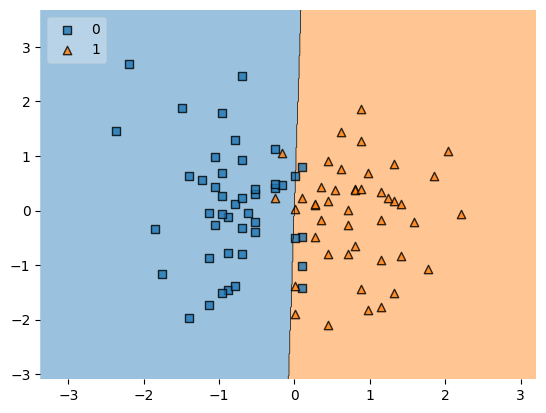

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)
# here .values is use because it is converting into numpy array

In [ ]:
import pickle
# here we are convering our train model into file and downloading it
pickle.dump(clf,open('model.pkl','wb'))